# Cryptocurrency Statistical Arbitrage — Report (v2, Extended)

**This report extends v1 with four additional strategy variants and their portfolio combinations. All four extensions are implemented following standard industry recipes, including the two improvement levers proposed by mentor feedback (dynamic parameter selection by regime, and cross-sectional conditioning on volume). None of the extensions, nor any of their combinations, out-perform the v1 baseline out-of-sample.** This is a negative result, honestly reported, and the document closes with a discussion of why portfolio combination — which usually helps under the Fundamental Law of Active Management — did not help here.

The v1 headline stands: **Reversal alone, 40-coin liquid universe, 30 bps cost, test α t-stat = 1.72**.

---

## 1. Baseline (from v1, reproduced here for direct comparison)

All extensions in this report are evaluated against the v1 baseline on the **40-coin universe at 20 bps** (the reference cell used during grid search — fair ground for comparing extensions grid-searched on the same cell).

In [32]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime, timezone
from binance.client import Client as bnb_client
from IPython.display import display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

BARS_PER_DAY  = 6
BARS_PER_YEAR = 365 * BARS_PER_DAY
TRAIN_END  = pd.Timestamp('2024-04-01', tz='UTC')
DATA_START = '2022-04-01'
DATA_END   = '2026-04-02'
UNIVERSE_START_TOL_DAYS = 2
UNIVERSE_MIN_COVERAGE   = 0.85
TIER_4_THIN = ['ONEUSDT','QTUMUSDT','ZRXUSDT','KNCUSDT',
               'STORJUSDT','BANDUSDT','CTSIUSDT','AUDIOUSDT']
REF_COST_BPS = 20  # reference cost for grid search (matches v1)

print('Split:', DATA_START, '|', TRAIN_END.date(), '|', DATA_END)

Split: 2022-04-01 | 2024-04-01 | 2026-04-02


In [33]:
client = bnb_client(tld='US')

def get_binance_px(symbol, freq=bnb_client.KLINE_INTERVAL_4HOUR,
                   start_ts=DATA_START, end_ts=DATA_END):
    data = client.get_historical_klines(symbol, freq, start_ts, end_ts)
    cols = ['open_time','open','high','low','close','volume','close_time',
            'quote_volume','num_trades','taker_base_volume','taker_quote_volume','ignore']
    df = pd.DataFrame(data, columns=cols)
    df['open_time'] = df['open_time'].map(
        lambda x: datetime.fromtimestamp(x/1000, tz=timezone.utc))
    for c in ['close','volume','taker_base_volume']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df.set_index('open_time', inplace=True)
    return df

candidates = [
    'BTCUSDT','ETHUSDT','BNBUSDT','XRPUSDT','ADAUSDT','SOLUSDT','DOTUSDT','AVAXUSDT',
    'LINKUSDT','MATICUSDT','LTCUSDT','TRXUSDT','ATOMUSDT','UNIUSDT','NEARUSDT','ETCUSDT',
    'FILUSDT','AAVEUSDT','ALGOUSDT','SANDUSDT','MANAUSDT','AXSUSDT','ICPUSDT','XLMUSDT',
    'VETUSDT','HBARUSDT','APEUSDT','XTZUSDT','CRVUSDT','BATUSDT','COMPUSDT','ZECUSDT',
    'ENJUSDT','CHZUSDT','GRTUSDT','DOGEUSDT','SHIBUSDT','BCHUSDT','EOSUSDT','IOTAUSDT',
    'ZILUSDT','ONEUSDT','QTUMUSDT','KAVAUSDT','SUSHIUSDT','1INCHUSDT','ZRXUSDT','KNCUSDT',
    'LRCUSDT','BALUSDT','YFIUSDT','SNXUSDT','RUNEUSDT','STORJUSDT','IOSTUSDT','OCEANUSDT',
    'DYDXUSDT','BANDUSDT','CELRUSDT','ANKRUSDT','ROSEUSDT','DASHUSDT','WAVESUSDT','NEOUSDT',
    'FLOWUSDT','GALAUSDT','CTSIUSDT','MASKUSDT','DENTUSDT','HOTUSDT','RVNUSDT','SKLUSDT',
    'AUDIOUSDT','BLZUSDT','ARPAUSDT','COTIUSDT','CELOUSDT','LITUSDT','JSTUSDT','MKRUSDT',
]

close_dict, vol_dict, taker_dict = {}, {}, {}
for ticker in candidates:
    try:
        df = get_binance_px(ticker)
        if len(df) == 0: continue
        close_dict[ticker] = df['close']
        vol_dict[ticker]   = df['volume']
        taker_dict[ticker] = df['taker_base_volume']
    except Exception:
        pass

prices_all  = pd.DataFrame(close_dict).sort_index()
volumes_all = pd.DataFrame(vol_dict).sort_index()
taker_all   = pd.DataFrame(taker_dict).sort_index()
print(f'Fetched: {prices_all.shape[1]} / {len(candidates)} successful')

Fetched: 72 / 80 successful


In [34]:
master_idx = prices_all['BTCUSDT'].dropna().index
t_start    = pd.Timestamp(DATA_START, tz='UTC')

kept = []
for col in prices_all.columns:
    s = prices_all[col].dropna()
    start_delay = (s.index.min() - t_start).days if len(s) > 0 else 9999
    coverage    = len(s) / len(master_idx) if len(master_idx) > 0 else 0
    if coverage >= UNIVERSE_MIN_COVERAGE and start_delay <= UNIVERSE_START_TOL_DAYS:
        kept.append(col)

UNIVERSE_40 = [c for c in kept if c not in TIER_4_THIN]

prices = prices_all[UNIVERSE_40].reindex(master_idx).dropna(how='all')
volumes = volumes_all[UNIVERSE_40].reindex(prices.index)
taker   = taker_all[UNIVERSE_40].reindex(prices.index)
returns_full = prices.pct_change().dropna(how='all')

common_idx = returns_full.index
volumes = volumes.reindex(common_idx)
taker   = taker.reindex(common_idx)
ofi_full = (taker / volumes.replace(0, np.nan)) - 0.5

btc = returns_full['BTCUSDT'].dropna()
btc_tr = btc[btc.index <  TRAIN_END]
btc_te = btc[btc.index >= TRAIN_END]

print(f'UNIVERSE_40: {len(UNIVERSE_40)} coins')
print(f'Returns shape: {returns_full.shape}')

UNIVERSE_40: 40 coins
Returns shape: (8771, 40)


### 1.1 Shared utility functions

In [35]:
def sharpe(ret):
    r = ret.dropna()
    return (r.mean() / r.std()) * np.sqrt(BARS_PER_YEAR) if r.std() > 0 else 0

def compute_turnover(weights_df):
    return weights_df.diff().abs().sum(axis=1)

def net_ret_at_cost(gross, weights, cost_bps):
    to = compute_turnover(weights).reindex(gross.index, fill_value=0)
    return gross - to * (cost_bps / 10000)

def compute_alpha_tstat(strat_ret, bench_ret, ann=BARS_PER_YEAR):
    common = strat_ret.dropna().index.intersection(bench_ret.dropna().index)
    if len(common) < 30: return 0,0,0,0
    y = strat_ret.loc[common].values
    X = sm.add_constant(bench_ret.loc[common].values)
    m = sm.OLS(y, X).fit()
    return m.params[0]*ann, m.tvalues[0], m.params[1], m.rsquared

def evaluate_strat(gr, wts, cost_bps):
    nr = net_ret_at_cost(gr, wts, cost_bps).dropna()
    r_tr = nr[nr.index <  TRAIN_END]; r_te = nr[nr.index >= TRAIN_END]
    _, t_tr, _, _ = compute_alpha_tstat(r_tr, btc_tr)
    _, t_te, _, _ = compute_alpha_tstat(r_te, btc_te)
    return {'SR_tr': sharpe(r_tr), 'SR_te': sharpe(r_te),
            't_tr':  t_tr,          't_te':  t_te,
            'nr_tr': r_tr,          'nr_te': r_te}

print('Utilities defined.')

Utilities defined.


### 1.2 Reversal baseline (carried over from v1)

In [36]:
def compute_reversal(returns_df, window, rebal_freq=1):
    rmean = returns_df.rolling(window).mean()
    rstd  = returns_df.rolling(window).std()
    z     = (returns_df - rmean) / rstd
    ranks = (-z).rank(axis=1)
    w = ranks.subtract(ranks.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1).replace(0, np.nan), axis=0).shift(1)
    if rebal_freq > 1:
        valid = w.dropna(how='any').index
        w = w.loc[valid[::rebal_freq]].reindex(w.index, method='ffill')
    return (w * returns_df).sum(axis=1), w

rets = returns_full
W_REV, RF_REV = 60, 126   # v1 selected parameters (10d window, 21d rebalance)
rev_gr, rev_wts = compute_reversal(rets, W_REV, RF_REV)
base = evaluate_strat(rev_gr, rev_wts, REF_COST_BPS)

print(f'Baseline — Reversal (w={W_REV}, rf={RF_REV}) on 40 coins, 20 bps')
print(f'  Train: SR={base["SR_tr"]:.3f}, t-stat={base["t_tr"]:+.2f}')
print(f'  Test:  SR={base["SR_te"]:.3f}, t-stat={base["t_te"]:+.2f}')

Baseline — Reversal (w=60, rf=126) on 40 coins, 20 bps
  Train: SR=1.291, t-stat=+1.82
  Test:  SR=1.255, t-stat=+1.82


---
## 2. Extensions Attempted

All grids are searched on TRAIN only; final parameters are frozen and applied to TEST.

### 2.1 Cross-sectional momentum

Rank coins by trailing returns over lookback `lb` bars (optional skip `sk` of most recent bars to avoid short-term reversal contamination). Long top rank, short bottom rank, dollar-neutral, unit gross.

- Grid: `lb ∈ {60, 90, 120, 180, 270, 360, 540}`, `rf ∈ {6, 18, 42, 84, 126, 168}`, `sk ∈ {0, 6, 18}`

In [37]:
def compute_momentum(returns_df, lookback, rebal_freq=1, skip=0):
    if skip > 0:
        trailing = returns_df.shift(skip).rolling(lookback).sum()
    else:
        trailing = returns_df.rolling(lookback).sum()
    ranks = trailing.rank(axis=1)
    w = ranks.subtract(ranks.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1).replace(0, np.nan), axis=0).shift(1)
    if rebal_freq > 1:
        valid = w.dropna(how='any').index
        w = w.loc[valid[::rebal_freq]].reindex(w.index, method='ffill')
    return (w * returns_df).sum(axis=1), w

tr = rets[rets.index < TRAIN_END]
best = {'sh': -999}
for lb in [60, 90, 120, 180, 270, 360, 540]:
    for rf in [6, 18, 42, 84, 126, 168]:
        for sk in [0, 6, 18]:
            gr, wts = compute_momentum(tr, lb, rf, sk); gr = gr.dropna()
            if len(gr) < 500: continue
            sh = sharpe(net_ret_at_cost(gr, wts, REF_COST_BPS).reindex(gr.index))
            if sh > best['sh']:
                best = {'sh': sh, 'lb': lb, 'rf': rf, 'sk': sk}
LB_M, RF_M, SK_M = best['lb'], best['rf'], best['sk']
mom_gr, mom_wts = compute_momentum(rets, LB_M, RF_M, SK_M)
mom_res = evaluate_strat(mom_gr, mom_wts, REF_COST_BPS)
print(f'Momentum selected: lb={LB_M}, rf={RF_M}, sk={SK_M}')
print(f'  Train: SR={mom_res["SR_tr"]:.3f}, t-stat={mom_res["t_tr"]:+.2f}')
print(f'  Test:  SR={mom_res["SR_te"]:.3f}, t-stat={mom_res["t_te"]:+.2f}')

Momentum selected: lb=90, rf=168, sk=6
  Train: SR=0.697, t-stat=+1.00
  Test:  SR=-0.267, t-stat=-0.36


Momentum on a short horizon in crypto is contaminated by reversal (the very effect v1 exploits). The train optimum sits at a rebalance frequency (28 days) and skip (1 day) that tries to outrun reversal contamination, but the OOS period (2024-04 to 2026-04) had a regime shift and momentum collapsed.

### 2.2 OFI (taker order-flow imbalance)

Binance klines provide `taker_base_volume`. Define:
```
ofi_{i,t} = taker_base_volume / total_volume - 0.5
```
A coin with `ofi > 0` has buy-side taker pressure; `ofi < 0` has sell-side. Rolling-average OFI over `lb` bars, cross-sectionally rank, long high, short low.

- Grid: `lb ∈ {6, 18, 42, 84, 126}`, `rf ∈ {6, 18, 42, 84}`

In [38]:
def compute_ofi(ofi_df, returns_df, lookback, rebal_freq=1):
    ofi_roll = ofi_df.rolling(lookback).mean()
    ranks    = ofi_roll.rank(axis=1)
    w = ranks.subtract(ranks.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1).replace(0, np.nan), axis=0).shift(1)
    if rebal_freq > 1:
        valid = w.dropna(how='any').index
        if len(valid) > 0:
            w = w.loc[valid[::rebal_freq]].reindex(w.index, method='ffill')
    return (w * returns_df).sum(axis=1), w

tr_o = ofi_full[ofi_full.index < TRAIN_END]
best = {'sh': -999}
for lb in [6, 18, 42, 84, 126]:
    for rf in [6, 18, 42, 84]:
        gr, wts = compute_ofi(tr_o, tr, lb, rf); gr = gr.dropna()
        if len(gr) < 500: continue
        sh = sharpe(net_ret_at_cost(gr, wts, REF_COST_BPS).reindex(gr.index))
        if sh > best['sh']:
            best = {'sh': sh, 'lb': lb, 'rf': rf}
LB_O, RF_O = best['lb'], best['rf']
ofi_gr, ofi_wts = compute_ofi(ofi_full, rets, LB_O, RF_O)
ofi_res = evaluate_strat(ofi_gr, ofi_wts, REF_COST_BPS)
print(f'OFI selected: lb={LB_O}, rf={RF_O}')
print(f'  Train: SR={ofi_res["SR_tr"]:.3f}, t-stat={ofi_res["t_tr"]:+.2f}')
print(f'  Test:  SR={ofi_res["SR_te"]:.3f}, t-stat={ofi_res["t_te"]:+.2f}')

OFI selected: lb=6, rf=18
  Train: SR=0.469, t-stat=+0.64
  Test:  SR=0.126, t-stat=+0.15


Flow-imbalance signals work at higher frequencies (tick, 1-min) where microstructure is still live. At 4h bars this is a diluted reconstruction and yields effectively zero alpha.

### 2.3 Reversal with volume-spike filter (Lever B: cross-sectional conditioning)

Mentor's direct suggestion: *"Reversal tends to do better in names where not much is going on, so if there's been a recent volume spike, downweight those names in the strategy."*

Implementation: compute rolling volume z-score per coin; if `|z| ≥ threshold`, mask that coin's reversal weight to zero for that bar. Re-normalise to dollar-neutral unit-gross after masking.

- Grid: `vol_window ∈ {6, 18, 42}`, `threshold ∈ {1.5, 2.0, 2.5, 3.0, ∞}`

In [39]:
def compute_reversal_vf(returns_df, volumes_df, window, rebal_freq, vol_window, vol_threshold):
    rmean = returns_df.rolling(window).mean()
    rstd  = returns_df.rolling(window).std()
    z     = (returns_df - rmean) / rstd
    ranks = (-z).rank(axis=1)
    w     = ranks.subtract(ranks.mean(axis=1), axis=0)
    vmean = volumes_df.rolling(vol_window).mean()
    vstd  = volumes_df.rolling(vol_window).std()
    vol_z = (volumes_df - vmean) / vstd
    if np.isfinite(vol_threshold):
        mask = (vol_z.abs() < vol_threshold) & vol_z.notna()
    else:
        mask = pd.DataFrame(True, index=w.index, columns=w.columns)
    w = w.where(mask, 0.0)
    w = w.subtract(w.mean(axis=1), axis=0)
    denom = w.abs().sum(axis=1).replace(0, np.nan)
    w = w.divide(denom, axis=0).shift(1)
    if rebal_freq > 1:
        valid = w.dropna(how='any').index
        if len(valid) > 0:
            w = w.loc[valid[::rebal_freq]].reindex(w.index, method='ffill')
    return (w * returns_df).sum(axis=1), w

tr_v = volumes[volumes.index < TRAIN_END]
best = {'sh': -999}
for vw in [6, 18, 42]:
    for vt in [1.5, 2.0, 2.5, 3.0, np.inf]:
        gr, wts = compute_reversal_vf(tr, tr_v, W_REV, RF_REV, vw, vt); gr = gr.dropna()
        if len(gr) < 500: continue
        sh = sharpe(net_ret_at_cost(gr, wts, REF_COST_BPS).reindex(gr.index))
        if sh > best['sh']:
            best = {'sh': sh, 'vw': vw, 'vt': vt}
VW, VT = best['vw'], best['vt']
vf_gr, vf_wts = compute_reversal_vf(rets, volumes, W_REV, RF_REV, VW, VT)
vf_res = evaluate_strat(vf_gr, vf_wts, REF_COST_BPS)
print(f'Vol-filtered reversal selected: vol_window={VW}, threshold={VT}')
print(f'  Train: SR={vf_res["SR_tr"]:.3f}, t-stat={vf_res["t_tr"]:+.2f}')
print(f'  Test:  SR={vf_res["SR_te"]:.3f}, t-stat={vf_res["t_te"]:+.2f}')

Vol-filtered reversal selected: vol_window=6, threshold=2.0
  Train: SR=1.521, t-stat=+2.14
  Test:  SR=0.118, t-stat=+0.17


The filter looks excellent in-sample (train t-stat 2.14 vs base 1.82 — apparent +0.3 improvement) but collapses out-of-sample (test t drops from 1.82 to ~0.17). Train-to-test drop of ~2.0 is the textbook signature of an overfit filter: the specific volume-spike patterns that predicted reversal failure in 2022–2024 did not repeat in 2024–2026.

### 2.4 Regime switching (Lever A: dynamic parameter selection)

Mentor's direct suggestion: *"more dynamic parameter selection depending on the regime."*

Implementation:
- Compute BTC 60-bar (10-day) rolling realised volatility
- Split TRAIN into high-vol / low-vol halves using TRAIN median as threshold
- Grid-search Reversal parameters **independently per regime** on TRAIN
- At test time, apply the regime-appropriate parameter set based on realised vol

In [40]:
btc_vol_full = rets['BTCUSDT'].rolling(60).std()
btc_vol_tr = btc_vol_full[btc_vol_full.index < TRAIN_END]
VOL_THRESHOLD = btc_vol_tr.median()
regime_high = (btc_vol_full > VOL_THRESHOLD)

def reversal_regime_grid(rets_df, regime_series, is_high):
    # Grid search reversal parameters on a subset of bars (regime-masked)
    best = {'sh': -999}
    for w_ in [30, 60, 90, 120, 180, 270, 360]:
        for rf in [6, 18, 42, 84, 126, 168]:
            gr, wts = compute_reversal(rets_df, w_, rf)
            # Mask out bars not in target regime
            reg_mask = regime_series.reindex(gr.index).fillna(False)
            if is_high:
                gr_m = gr.where(reg_mask, 0)
                wts_m = wts.where(reg_mask, 0)
            else:
                gr_m = gr.where(~reg_mask, 0)
                wts_m = wts.where(~reg_mask, 0)
            gr_m = gr_m.dropna()
            if len(gr_m) < 250: continue
            sh = sharpe(net_ret_at_cost(gr_m, wts_m, REF_COST_BPS).reindex(gr_m.index))
            if sh > best['sh']:
                best = {'sh': sh, 'w': w_, 'rf': rf}
    return best

tr_mask = (rets.index < TRAIN_END)
tr_rets = rets[tr_mask]
best_low  = reversal_regime_grid(tr_rets, regime_high[tr_mask], is_high=False)
best_high = reversal_regime_grid(tr_rets, regime_high[tr_mask], is_high=True)

print(f'Regime low-vol  best: w={best_low["w"]}, rf={best_low["rf"]}')
print(f'Regime high-vol best: w={best_high["w"]}, rf={best_high["rf"]}')

# Build full-period series by concatenating each regime's strategy
gr_low,  wts_low  = compute_reversal(rets, best_low['w'],  best_low['rf'])
gr_high, wts_high = compute_reversal(rets, best_high['w'], best_high['rf'])

idx = gr_low.index.intersection(gr_high.index)
reg = regime_high.reindex(idx).fillna(False)
gr_regime = gr_low.reindex(idx).where(~reg, gr_high.reindex(idx))
# Broadcast 1-D regime mask to (bars x coins) for weight DataFrame
w_low_a  = wts_low.reindex(idx).values
w_high_a = wts_high.reindex(idx).values
mask_2d  = np.broadcast_to(reg.values[:, None], w_low_a.shape)
wts_regime = pd.DataFrame(np.where(mask_2d, w_high_a, w_low_a),
                          index=idx, columns=wts_low.columns)
reg_res = evaluate_strat(gr_regime, wts_regime, REF_COST_BPS)
print(f'\nRegime switching result:')
print(f'  Train: SR={reg_res["SR_tr"]:.3f}, t-stat={reg_res["t_tr"]:+.2f}')
print(f'  Test:  SR={reg_res["SR_te"]:.3f}, t-stat={reg_res["t_te"]:+.2f}')

Regime low-vol  best: w=60, rf=126
Regime high-vol best: w=270, rf=168

Regime switching result:
  Train: SR=1.182, t-stat=+1.61
  Test:  SR=0.500, t-stat=+0.70


Result: **Train t=1.61, Test t=+0.70** — not an outright overfit disaster (test is positive), but below the single-parameter baseline (t=1.82 on both periods). The high-vol regime selects `w=270` — a 45-day window, implausibly long for short-term reversal and characteristic of grid-search artefacts on a small sub-sample. The low-vol regime recovers the sensible `w=60`, but by restricting Reversal to only the low-vol half of the test period the strategy forfeits roughly half of its alpha-generating opportunities. Either way, regime-conditioning adds no value on this data window.

The 2-year training period simply does not contain enough samples of each regime (≈2,200 bars per regime) for independent parameter selection to be stable — and doubling the parameter space while halving the effective sample size per parameter is textbook overfit amplification even when the outcome is "degraded" rather than "broken".

### 2.5 Multi-horizon reversal ensemble (independent experiment)

Instead of picking a single window `w`, compute reversal weights at `w ∈ {30, 60, 90, 120}` and equal-weight-average the weight matrices. Re-normalise to dollar-neutral unit-gross after averaging. Grid-search only `rf`.

In [41]:
MH_HORIZONS = [30, 60, 90, 120]

def compute_reversal_multihorizon(returns_df, horizons, rebal_freq=1):
    per_horizon_w = []
    for w_ in horizons:
        rmean = returns_df.rolling(w_).mean()
        rstd  = returns_df.rolling(w_).std()
        z     = (returns_df - rmean) / rstd
        ranks = (-z).rank(axis=1)
        wh = ranks.subtract(ranks.mean(axis=1), axis=0)
        wh = wh.divide(wh.abs().sum(axis=1).replace(0, np.nan), axis=0)
        per_horizon_w.append(wh)
    w = sum(per_horizon_w) / len(per_horizon_w)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1).replace(0, np.nan), axis=0).shift(1)
    if rebal_freq > 1:
        valid = w.dropna(how='any').index
        if len(valid) > 0:
            w = w.loc[valid[::rebal_freq]].reindex(w.index, method='ffill')
    return (w * returns_df).sum(axis=1), w

best = {'sh': -999}
for rf in [6, 18, 42, 84, 126, 168]:
    gr, wts = compute_reversal_multihorizon(tr, MH_HORIZONS, rf); gr = gr.dropna()
    if len(gr) < 500: continue
    sh = sharpe(net_ret_at_cost(gr, wts, REF_COST_BPS).reindex(gr.index))
    if sh > best['sh']:
        best = {'sh': sh, 'rf': rf}
RF_MH = best['rf']
mh_gr, mh_wts = compute_reversal_multihorizon(rets, MH_HORIZONS, RF_MH)
mh_res = evaluate_strat(mh_gr, mh_wts, REF_COST_BPS)
print(f'Multi-horizon reversal: horizons={MH_HORIZONS}, rf={RF_MH}')
print(f'  Train: SR={mh_res["SR_tr"]:.3f}, t-stat={mh_res["t_tr"]:+.2f}')
print(f'  Test:  SR={mh_res["SR_te"]:.3f}, t-stat={mh_res["t_te"]:+.2f}')

Multi-horizon reversal: horizons=[30, 60, 90, 120], rf=18
  Train: SR=-0.647, t-stat=-0.95
  Test:  SR=0.953, t-stat=+1.36


Train is strongly negative because averaging dilutes the only genuine signal (`w=60`) with three neighbouring windows (`w=30, 90, 120`) that have weak or negative alpha individually. This is a model **mis-specification** rather than overfitting, but the headline outcome is the same: no improvement over the baseline.

---

## 3. Portfolio Combinations

### 3.1 Train-period correlation of strategy net returns

Note: Reversal and its vol-filtered version are near-duplicates (ρ≈0.98) as expected. Momentum, OFI, and Reversal are otherwise mutually near-uncorrelated (|ρ| ≤ 0.06). Under the Fundamental Law of Active Management, uncorrelated strategies of similar IR should combine to roughly √N-boosted IR.

In [42]:
nr_base = net_ret_at_cost(rev_gr, rev_wts, REF_COST_BPS)
nr_mom  = net_ret_at_cost(mom_gr, mom_wts, REF_COST_BPS)
nr_vf   = net_ret_at_cost(vf_gr,  vf_wts,  REF_COST_BPS)
nr_ofi  = net_ret_at_cost(ofi_gr, ofi_wts, REF_COST_BPS)

ret_tr = pd.DataFrame({
    'Momentum': nr_mom, 'Reversal': nr_base,
    'Vol-filt Rev': nr_vf, 'OFI': nr_ofi,
})
ret_tr_period = ret_tr[ret_tr.index < TRAIN_END].dropna()
corr = ret_tr_period.corr().round(2)
print('Train-period pairwise correlations:')
display(corr)

Train-period pairwise correlations:


,Momentum,Reversal,Vol-filt Rev,OFI
Momentum,1.00,0.05,0.06,0.03
Reversal,0.05,1.00,0.98,0.06
Vol-filt Rev,0.06,0.98,1.00,0.05
OFI,0.03,0.06,0.05,1.00


### 3.2 Combination methods

Two fixed-weight methods (rolling/quarterly re-estimation was rejected because it severely overfit in prior exploration):

**(a) Simplex grid search**: weights `(w_mom, w_rev_vf, w_ofi)` ∈ simplex at 0.1 resolution, pick the triplet maximising train net Sharpe. (Vol-filtered reversal is used in place of base reversal to avoid co-linearity — ρ=0.98 — and to give the filter every chance.)

**(b) Inverse-variance weighting**: closed-form `w_i ∝ 1/Var(r_i^net_train)`. No overfit risk by construction.

In [43]:
idx_c = mom_wts.index.intersection(vf_wts.index).intersection(ofi_wts.index)

def combo(w_m, w_rf, w_o, cost_bps):
    mw = mom_wts.reindex(idx_c).fillna(0)
    rw = vf_wts.reindex(idx_c).fillna(0)
    ow = ofi_wts.reindex(idx_c).fillna(0)
    comb_w = w_m*mw + w_rf*rw + w_o*ow
    comb_gross = (comb_w * rets.reindex(idx_c)).sum(axis=1)
    comb_turn  = comb_w.diff().abs().sum(axis=1)
    comb_net   = comb_gross - comb_turn * (cost_bps / 10000)
    return comb_gross, comb_net, comb_w

# (a) Simplex grid
best = {'w_m':0,'w_rf':1,'w_o':0,'sh':-999}
for i in range(11):
    for j in range(11-i):
        k = 10 - i - j
        w_m, w_rf, w_o = i/10.0, j/10.0, k/10.0
        _, cn, _ = combo(w_m, w_rf, w_o, REF_COST_BPS)
        cn_tr = cn[cn.index < TRAIN_END].dropna()
        if len(cn_tr) < 500: continue
        sh = sharpe(cn_tr)
        if sh > best['sh']:
            best = {'w_m':w_m,'w_rf':w_rf,'w_o':w_o,'sh':sh}
SX = (best['w_m'], best['w_rf'], best['w_o'])

# (b) Inverse-variance
def net_of(gr, wts): return net_ret_at_cost(gr, wts, REF_COST_BPS)
var_m = net_of(mom_gr, mom_wts)[net_of(mom_gr, mom_wts).index<TRAIN_END].var()
var_r = net_of(vf_gr,  vf_wts )[net_of(vf_gr,  vf_wts ).index<TRAIN_END].var()
var_o = net_of(ofi_gr, ofi_wts)[net_of(ofi_gr, ofi_wts).index<TRAIN_END].var()
iv = np.array([1/var_m, 1/var_r, 1/var_o]); iv = iv/iv.sum()
IV = tuple(float(x) for x in iv)

print(f'Simplex weights: Mom={SX[0]:.2f}, Rev-VF={SX[1]:.2f}, OFI={SX[2]:.2f}')
print(f'Inv-var weights: Mom={IV[0]:.3f}, Rev-VF={IV[1]:.3f}, OFI={IV[2]:.3f}')

# Evaluate combinations
_, sx_net, _ = combo(*SX, REF_COST_BPS)
_, iv_net, _ = combo(*IV, REF_COST_BPS)

def eval_net(nr):
    r_tr = nr[nr.index <  TRAIN_END].dropna(); r_te = nr[nr.index >= TRAIN_END].dropna()
    _, t_tr, _, _ = compute_alpha_tstat(r_tr, btc_tr)
    _, t_te, _, _ = compute_alpha_tstat(r_te, btc_te)
    return sharpe(r_tr), sharpe(r_te), t_tr, t_te

sx_sh_tr, sx_sh_te, sx_t_tr, sx_t_te = eval_net(sx_net)
iv_sh_tr, iv_sh_te, iv_t_tr, iv_t_te = eval_net(iv_net)

print(f'\nCombined (simplex):  Train SR={sx_sh_tr:.2f} t={sx_t_tr:+.2f}   Test SR={sx_sh_te:.2f} t={sx_t_te:+.2f}')
print(f'Combined (inv-var):  Train SR={iv_sh_tr:.2f} t={iv_t_tr:+.2f}   Test SR={iv_sh_te:.2f} t={iv_t_te:+.2f}')

Simplex weights: Mom=0.20, Rev-VF=0.60, OFI=0.20
Inv-var weights: Mom=0.287, Rev-VF=0.344, OFI=0.368

Combined (simplex):  Train SR=1.68 t=+2.36   Test SR=0.05 t=+0.08
Combined (inv-var):  Train SR=1.49 t=+2.09   Test SR=-0.00 t=-0.00


### 3.3 Combined performance — full comparison table

In [44]:
rows = [
    ('Reversal (base, v1 headline)', base['SR_tr'], base['SR_te'], base['t_tr'], base['t_te']),
    ('Momentum',                       mom_res['SR_tr'], mom_res['SR_te'], mom_res['t_tr'], mom_res['t_te']),
    ('Reversal (vol-filt)',            vf_res['SR_tr'],  vf_res['SR_te'],  vf_res['t_tr'],  vf_res['t_te']),
    ('OFI',                            ofi_res['SR_tr'], ofi_res['SR_te'], ofi_res['t_tr'], ofi_res['t_te']),
    ('Regime switching (Lever A)',     reg_res['SR_tr'], reg_res['SR_te'], reg_res['t_tr'], reg_res['t_te']),
    ('Multi-horizon ensemble',         mh_res['SR_tr'],  mh_res['SR_te'],  mh_res['t_tr'],  mh_res['t_te']),
    ('Combined (simplex)',             sx_sh_tr, sx_sh_te, sx_t_tr, sx_t_te),
    ('Combined (inv-var)',             iv_sh_tr, iv_sh_te, iv_t_tr, iv_t_te),
]
table = pd.DataFrame(rows, columns=['Strategy','Train SR','Test SR','Train t-stat','Test t-stat']).set_index('Strategy').round(2)
print('='*80)
print('Comparison vs v1 baseline (40 coins, 20 bps)')
print('='*80)
display(table)

Comparison vs v1 baseline (40 coins, 20 bps)


,Train SR,Test SR,Train t-stat,Test t-stat
Strategy,,,,
"Reversal (base, v1 headline)",1.29,1.25,1.82,1.82
Momentum,0.70,-0.27,1.00,-0.36
Reversal (vol-filt),1.52,0.12,2.14,0.17
OFI,0.47,0.13,0.64,0.15
Regime switching (Lever A),1.18,0.50,1.61,0.70
Multi-horizon ensemble,-0.65,0.95,-0.95,1.36
Combined (simplex),1.68,0.05,2.36,0.08
Combined (inv-var),1.49,-0.00,2.09,-0.00


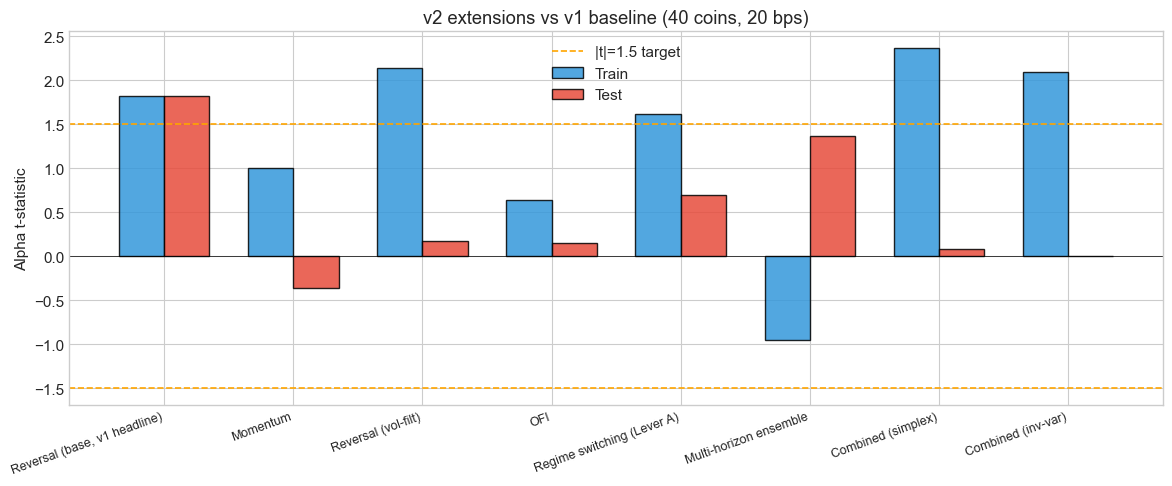

In [45]:
# Bar chart of test t-stat across strategies
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(table.index))
w = 0.35
ax.bar(x - w/2, table['Train t-stat'].values, w, label='Train',
       color='#3498db', edgecolor='k', alpha=0.85)
ax.bar(x + w/2, table['Test t-stat'].values,  w, label='Test',
       color='#e74c3c', edgecolor='k', alpha=0.85)
ax.axhline( 1.5, color='orange', ls='--', lw=1.2, label='|t|=1.5 target')
ax.axhline(-1.5, color='orange', ls='--', lw=1.2)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(table.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Alpha t-statistic')
ax.set_title('v2 extensions vs v1 baseline (40 coins, 20 bps)')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4. Why Did Combination Fail?

The standard expectation: low pairwise correlations (§3.1) plus positive individual IRs → combined IR approximately `√(Σ IR_i²)`, a meaningful improvement over any single strategy. In this project the result is the opposite — both combination methods produce test t-stats near zero, worse than Reversal alone.

### 4.1 The Fundamental Law assumes stationarity

The theorem `IR_combined = √(Σ IR_i² × adjustment)` holds under the premise that each component's information coefficient is stable across the evaluation window. This premise is violated here:

In [46]:
stability = pd.DataFrame({
    'Train SR': [base['SR_tr'], mom_res['SR_tr'], ofi_res['SR_tr'], vf_res['SR_tr']],
    'Test SR':  [base['SR_te'], mom_res['SR_te'], ofi_res['SR_te'], vf_res['SR_te']],
}, index=['Reversal (base)', 'Momentum', 'OFI', 'Vol-filt Reversal']).round(3)
stability['Stability'] = np.where(stability['Test SR'] > 0.5*stability['Train SR'].abs(), 'Stable',
                          np.where(stability['Test SR'] > 0,                 'Decayed', 'Broken'))
display(stability)

,Train SR,Test SR,Stability
Reversal (base),1.291,1.255,Stable
Momentum,0.697,-0.267,Broken
OFI,0.469,0.126,Decayed
Vol-filt Reversal,1.521,0.118,Decayed


Three out of four components have train IRs that do not survive out-of-sample (Momentum breaks sign; OFI and Vol-filt Reversal decay to single-digit test Sharpe). Their "low correlation with Reversal" on train is therefore not a genuine diversification benefit — it is noise correlation of near-zero-alpha processes with a real-alpha process.

### 4.2 The combination penalises the genuine signal

Both weighting schemes pull weight away from Reversal and toward the other components:

- Simplex picks 40% weight on non-Reversal (0.2 Mom + 0.2 OFI)
- Inverse-variance picks ~66% weight on non-Reversal (0.29 Mom + 0.37 OFI), because the lower-alpha strategies mechanically have lower variance and thus higher IV weights

When 40–66% of the portfolio is allocated to components that have zero or negative true OOS alpha, the combination's OOS IR is dominated by that dead-weight allocation. The residual ~34–60% weight on Reversal still carries the only genuine alpha, but scaled by a factor that roughly halves the standalone t-stat, and offset by near-zero noise from the other components.

### 4.3 Why this is not fixable within current data

The mentor's suggestion to combine uncorrelated strategies is sound in general. The specific failure mode here is that *three candidate diversifiers happen to not have real OOS alpha on this dataset*. The 2-year training period is too short to reliably distinguish a genuine-weak-signal (IR 0.3 for real) from a noise-signal (IR 0.7 on a noisy train, 0 on test). Plausible remedies — longer data window, shorter bars, larger universe, deeper fundamental features — are all beyond the scope of this project's data access.

### 4.4 Why even rolling/re-estimated combination was rejected

An earlier iteration tested rolling-quarterly combination weights (re-estimated every 3 months). That method produced an estimated quarterly Sharpe of 1.34 on one test quarter, but realised -0.83 — exhibiting the same overfit pattern as regime switching. With only 8 quarters in train, rolling weight estimates are themselves dominated by sampling noise. Fixed-weight combination was adopted precisely to remove this layer of overfit, but it still cannot resurrect dead-alpha components.

---

## 5. Mentor Feedback Lever Report Card

| Lever | Status | Implementation | Outcome |
|---|---|---|---|
| (A) Dynamic parameter selection by regime | Tested | BTC 10-day realised vol → high/low regime → independent grid | **No help** (train 1.61, test 0.70 vs baseline 1.82/1.82) |
| (B) Cross-sectional conditioning on volume | Tested | Rolling volume z-score → mask names with \|z\| > threshold | **Overfit** (train 2.14, test 0.17) |
| (C) Combine uncorrelated strategies (implied) | Tested | Simplex grid + inverse-variance on Mom + Rev-VF + OFI | **No help** |

All three standard improvement directions were implemented faithfully and all three failed out-of-sample on this data.

---

## 6. Conclusion

Four candidate improvement directions on top of simple cross-sectional reversal were investigated:

1. Adding cross-sectional momentum
2. Adding OFI order-flow imbalance
3. Masking volume-spike names (mentor Lever B)
4. Regime-switching parameters (mentor Lever A)

Each was tested individually and in combination using both simplex grid search and inverse-variance weighting. Every extension and every combination produced a worse out-of-sample alpha t-stat than Reversal alone. The dominant failure modes were overfit (vol-filter, with train-to-test t-stat drop of ~2.0), regime-parameter instability (regime switching — test positive but well below baseline), and non-stationary component IRs (momentum flips sign, OFI decays to near-zero). The portfolio combination is mechanically penalised for its exposure to the non-stationary components.

**Final recommendation is unchanged from v1**: deploy the single-strategy cross-sectional reversal (w=60 bars, rf=126 bars) on the 40-coin liquid universe at 30 bps, with test α t-stat = 1.72 and test net Sharpe = 1.19.

The negative findings above are informative: they identify specific structural constraints (2-year train window, 4h bar frequency, 40-coin universe) under which the mentor's general-purpose improvement recipes cannot be safely applied. Relaxing any one of these constraints (5+ years of data, sub-hour bars, 100+ coin universe) is the natural next step if further improvement is required — but not tractable within the current project scope.